In [1]:
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import unicodedata

In [2]:
df = pd.read_csv('DataframeFinal_2.csv')



In [3]:
columnas_target = ['diastolica_1', 'diastolica_2', 'diastolica_3', 
                   'sistolica_1', 'sistolica_2', 'sistolica_3' 
                   ]

# 1. Copiamos las columnas deseadas en el nuevo DataFrame df_target
df_presion = df[columnas_target].copy()

# 2. Eliminamos esas columnas del DataFrame original df
df = df.drop(columns=columnas_target)

In [4]:
df_presion.info()

<class 'pandas.DataFrame'>
RangeIndex: 2687 entries, 0 to 2686
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diastolica_1  2591 non-null   float64
 1   diastolica_2  2588 non-null   float64
 2   diastolica_3  2581 non-null   float64
 3   sistolica_1   2591 non-null   float64
 4   sistolica_2   2588 non-null   float64
 5   sistolica_3   2581 non-null   float64
dtypes: float64(6)
memory usage: 126.1 KB


In [5]:
# Cuenta cuántas filas tienen exactamente N valores nulos
resumen_nulos = df_presion.isnull().sum(axis=1).value_counts().sort_index()

print("Cantidad de filas por número de valores nulos:")
print(resumen_nulos)


Cantidad de filas por número de valores nulos:
0    2580
2       9
4       2
6      96
Name: count, dtype: int64


Eliminamos las filas con todo valores nulos (6)

In [6]:
df_presion = df_presion.dropna(subset=columnas_target)

In [7]:
# Cuenta cuántas filas tienen exactamente N valores nulos
resumen_nulos = df_presion.isnull().sum(axis=1).value_counts().sort_index()

print("Cantidad de filas por número de valores nulos:")
print(resumen_nulos)

Cantidad de filas por número de valores nulos:
0    2580
Name: count, dtype: int64


In [8]:
df_presion['pres_arterial_1'] = (df_presion['sistolica_1'] + 2 * df_presion['diastolica_1']) / 3
df_presion['pres_arterial_2'] = (df_presion['sistolica_2'] + 2 * df_presion['diastolica_2']) / 3
df_presion['pres_arterial_3'] = (df_presion['sistolica_3'] + 2 * df_presion['diastolica_3']) / 3



In [9]:
df_presion.info()

<class 'pandas.DataFrame'>
Index: 2580 entries, 0 to 2686
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   diastolica_1     2580 non-null   float64
 1   diastolica_2     2580 non-null   float64
 2   diastolica_3     2580 non-null   float64
 3   sistolica_1      2580 non-null   float64
 4   sistolica_2      2580 non-null   float64
 5   sistolica_3      2580 non-null   float64
 6   pres_arterial_1  2580 non-null   float64
 7   pres_arterial_2  2580 non-null   float64
 8   pres_arterial_3  2580 non-null   float64
dtypes: float64(9)
memory usage: 201.6 KB


**Table. Categories of BP in Adults\***

| BP Category | SBP | | DBP |
| :--- | :--- | :---: | :--- |
| **Normal** | <120 mm Hg | and | <80 mm Hg |
| **Elevated** | 120–129 mm Hg | and | <80 mm Hg |
| **Hypertension** | | | |
| &emsp;Stage 1 | 130–139 mm Hg | or | 80–89 mm Hg |
| &emsp;Stage 2 | ≥140 mm Hg | or | ≥90 mm Hg |

<br>

<small>\* Individuals with SBP and DBP in 2 categories should be designated to the higher BP category.</small>
<small><br>BP indicates blood pressure (based on an average of ≥2 careful readings obtained on ≥2 occasions, as detailed in Section 4); DBP, diastolic blood pressure; and SBP, systolic blood pressure.</small>

Fuente: https://www.ahajournals.org/doi/10.1161/HYP.0000000000000065


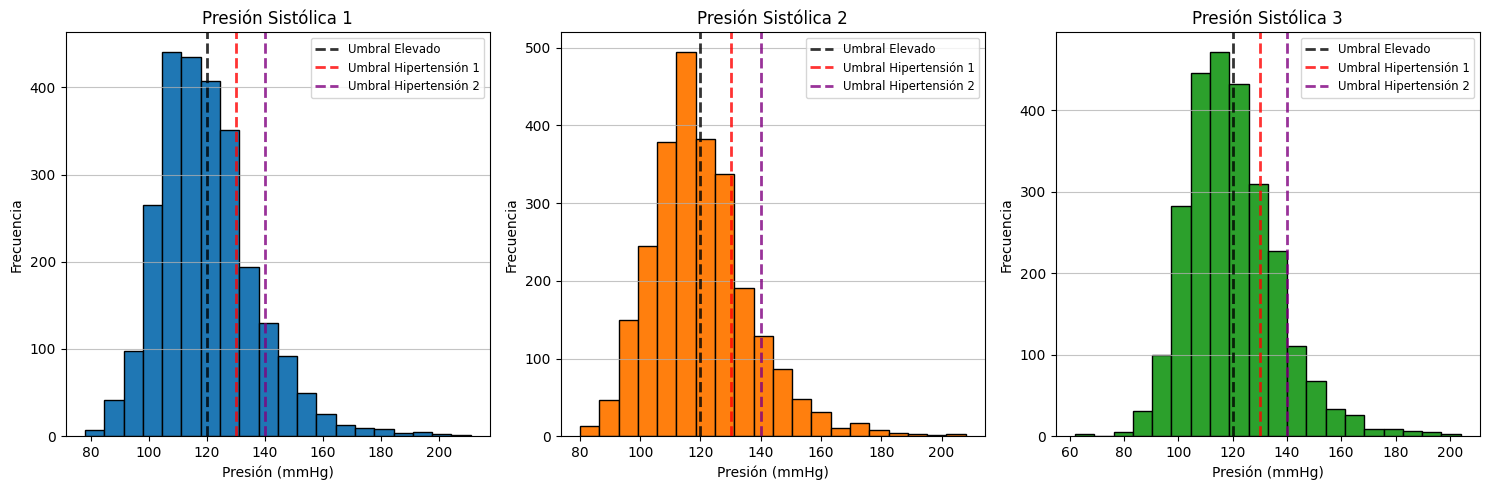

In [10]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['sistolica_1', 'sistolica_2', 'sistolica_3']
titulos = ['Presión Sistólica 1', 'Presión Sistólica 2', 'Presión Sistólica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


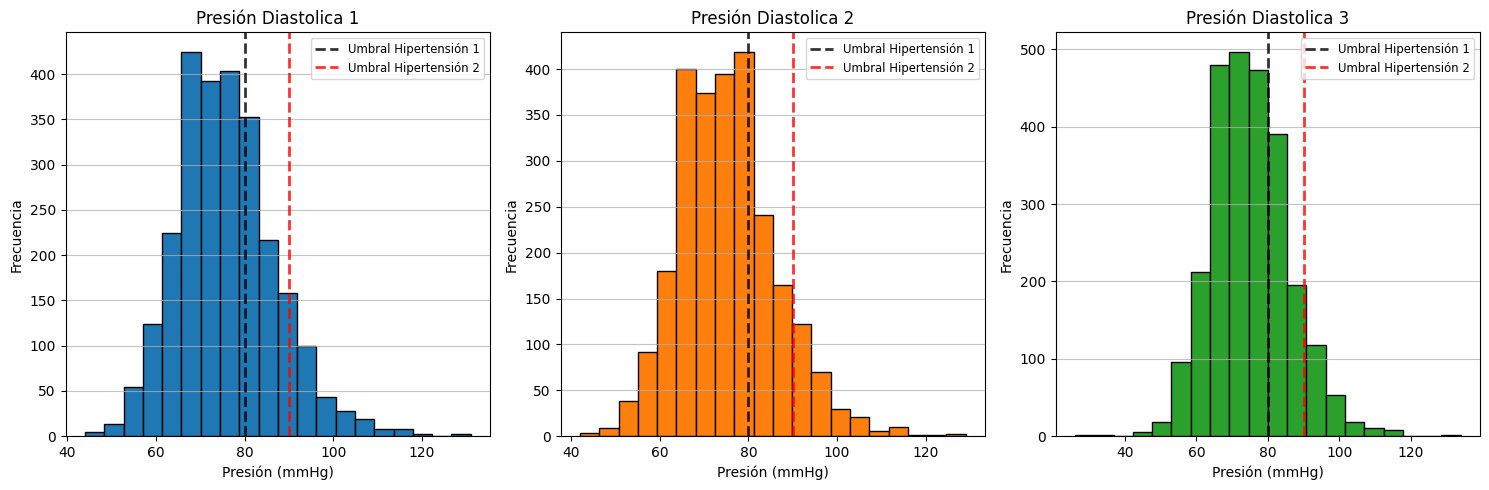

In [11]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['diastolica_1', 'diastolica_2', 'diastolica_3']
titulos = ['Presión Diastolica 1', 'Presión Diastolica 2', 'Presión Diastolica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    axes[i].legend(loc='upper right', fontsize='small')    
# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


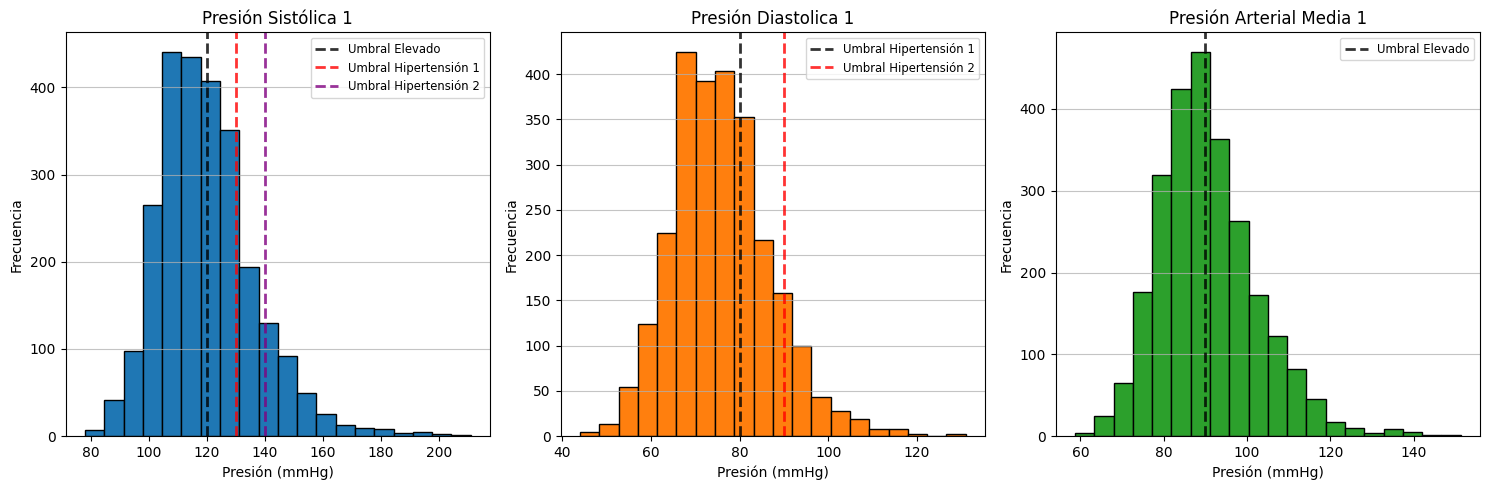

In [12]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['sistolica_1', 'diastolica_1', 'pres_arterial_1']
titulos = ['Presión Sistólica 1', 'Presión Diastolica 1', 'Presión Arterial Media 1']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


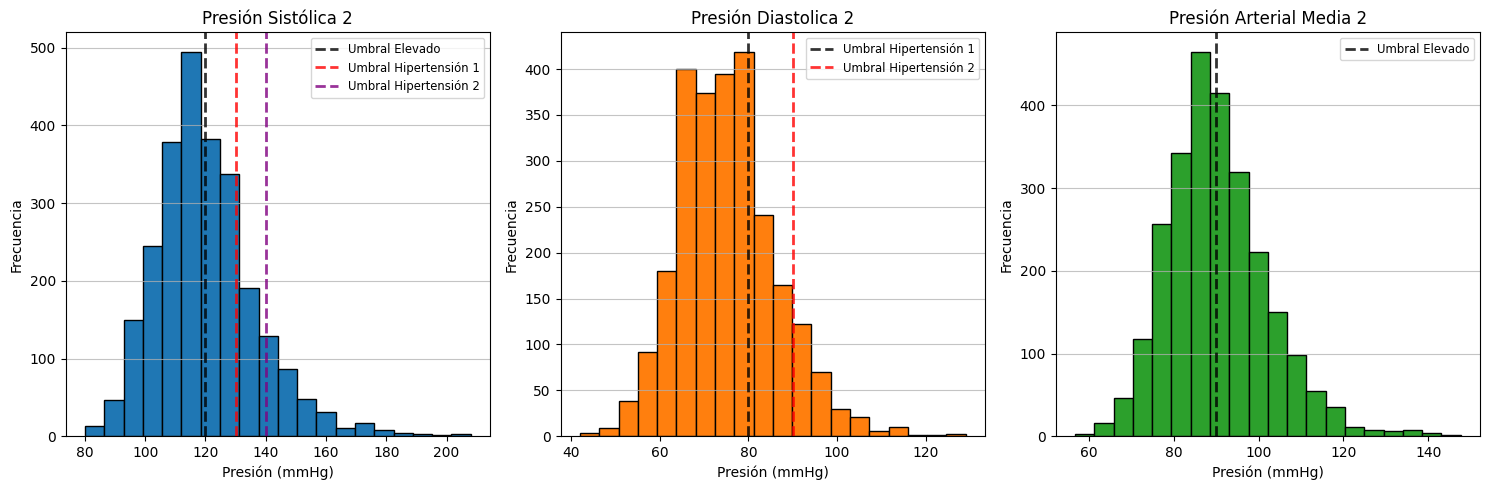

In [13]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['sistolica_2', 'diastolica_2', 'pres_arterial_2']
titulos = ['Presión Sistólica 2', 'Presión Diastolica 2', 'Presión Arterial Media 2']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


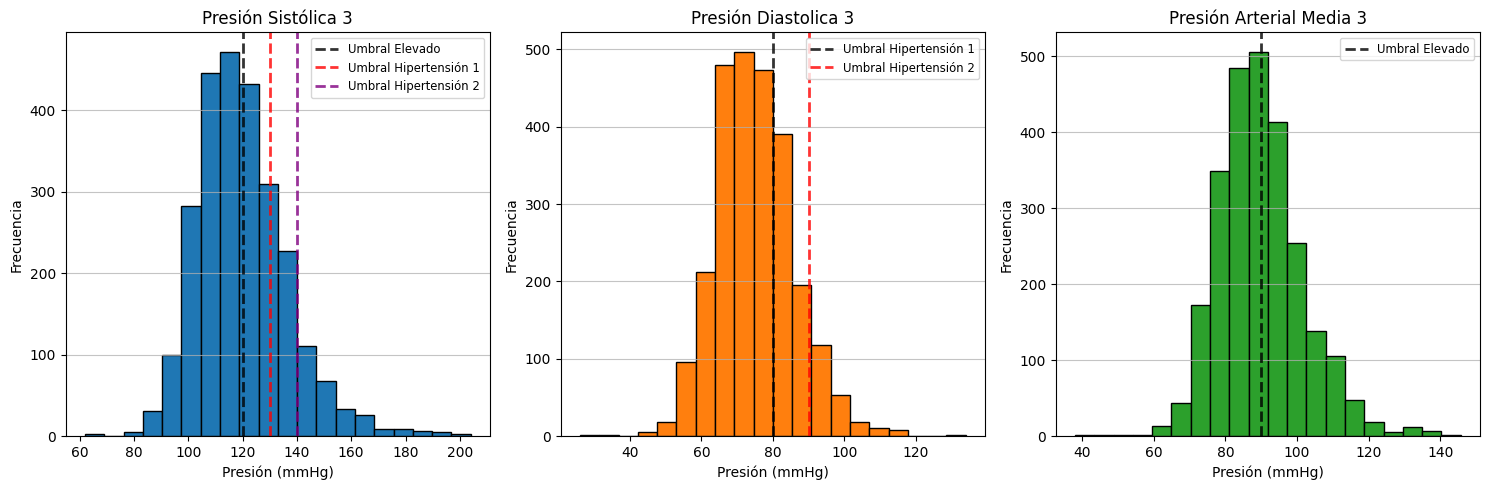

In [ ]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['sistolica_3', 'diastolica_3', 'pres_arterial_3']
titulos = ['Presión Sistólica 3', 'Presión Diastolica 3', 'Presión Arterial Media 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


In [15]:
# Definir las listas de columnas para cada cálculo
columnas_sis = ['sistolica_1', 'sistolica_2', 'sistolica_3']
columnas_dis = ['diastolica_1', 'diastolica_2', 'diastolica_3']

# Calcular la media ignorando automáticamente los valores nulos (NaN)
df_presion['pa_sis_media'] = df_presion[columnas_sis].mean(axis=1).round(0)
df_presion['pa_dis_media'] = df_presion[columnas_dis].mean(axis=1).round(0)

# Comprobar el resultado
df_presion[['sistolica_1', 'sistolica_2', 'sistolica_3', 'pa_sis_media', 
            'diastolica_1', 'diastolica_2', 'diastolica_3', 'pa_dis_media']].head()


,sistolica_1,sistolica_2,sistolica_3,pa_sis_media,diastolica_1,diastolica_2,diastolica_3,pa_dis_media
0,135.0,131.0,132.0,133.0,98.0,96.0,94.0,96.0
1,121.0,117.0,113.0,117.0,84.0,76.0,76.0,79.0
2,111.0,112.0,104.0,109.0,79.0,80.0,76.0,78.0
3,110.0,120.0,115.0,115.0,72.0,74.0,75.0,74.0
4,99.0,110.0,123.0,111.0,69.0,68.0,67.0,68.0


In [16]:

df_presion['pres_arterial_media'] = (df_presion['pa_sis_media'] + 2 * df_presion['pa_dis_media']) / 3



In [17]:
df_presion.info()

<class 'pandas.DataFrame'>
Index: 2580 entries, 0 to 2686
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   diastolica_1         2580 non-null   float64
 1   diastolica_2         2580 non-null   float64
 2   diastolica_3         2580 non-null   float64
 3   sistolica_1          2580 non-null   float64
 4   sistolica_2          2580 non-null   float64
 5   sistolica_3          2580 non-null   float64
 6   pres_arterial_1      2580 non-null   float64
 7   pres_arterial_2      2580 non-null   float64
 8   pres_arterial_3      2580 non-null   float64
 9   pa_sis_media         2580 non-null   float64
 10  pa_dis_media         2580 non-null   float64
 11  pres_arterial_media  2580 non-null   float64
dtypes: float64(12)
memory usage: 262.0 KB


In [18]:
df_presion.head()

,diastolica_1,diastolica_2,diastolica_3,sistolica_1,sistolica_2,sistolica_3,pres_arterial_1,pres_arterial_2,pres_arterial_3,pa_sis_media,pa_dis_media,pres_arterial_media
0,98.0,96.0,94.0,135.0,131.0,132.0,110.333333,107.666667,106.666667,133.0,96.0,108.333333
1,84.0,76.0,76.0,121.0,117.0,113.0,96.333333,89.666667,88.333333,117.0,79.0,91.666667
2,79.0,80.0,76.0,111.0,112.0,104.0,89.666667,90.666667,85.333333,109.0,78.0,88.333333
3,72.0,74.0,75.0,110.0,120.0,115.0,84.666667,89.333333,88.333333,115.0,74.0,87.666667
4,69.0,68.0,67.0,99.0,110.0,123.0,79.000000,82.000000,85.666667,111.0,68.0,82.333333


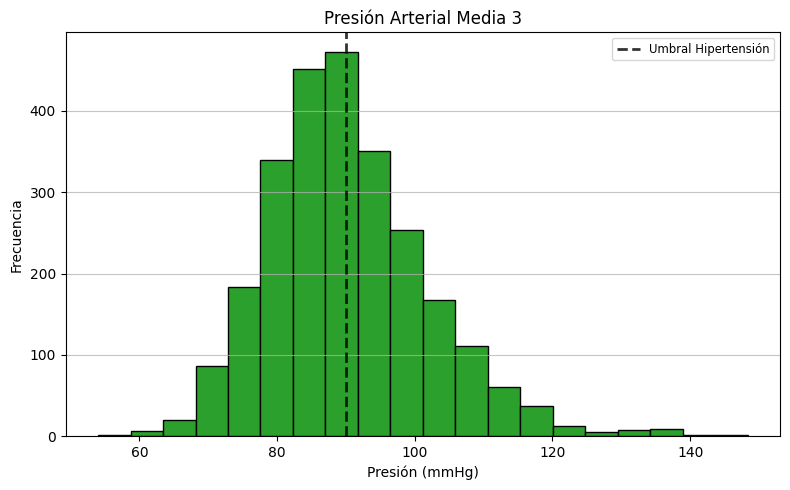

In [20]:
# Configurar el tamaño de la figura (1 solo gráfico)
fig, ax = plt.subplots(figsize=(8, 5))

# Definimos los umbrales específicos para la Presión Arterial Media
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Hipertensión'}
]

# Nombre de la variable en el dataframe (asegúrate de que coincida con tu df, ej: 'pres_arterial_media' o 'pres_arterial_3')
columna = 'pres_arterial_media'

# Crear el histograma
# Usamos dropna() para evitar errores con valores nulos (NaN)
ax.hist(df_presion[columna].dropna(), bins=20, color='#2ca02c', edgecolor='black') # Verde
ax.set_title('Presión Arterial Media 3')
ax.set_xlabel('Presión (mmHg)')
ax.set_ylabel('Frecuencia')
ax.grid(axis='y', alpha=0.75)

# Añadir las líneas de los umbrales
for umbral in umbralesMed:
    ax.axvline(
        x=umbral['valor'], 
        color=umbral['color'], 
        linestyle='--', 
        alpha=0.8, 
        linewidth=2, 
        label=umbral['etiqueta']
    )

# Mostrar la leyenda
ax.legend(loc='upper right', fontsize='small')

# Ajustar el espaciado
plt.tight_layout()

# Mostrar la gráfica
plt.show()


In [24]:
df['pres_arterial_media'] = df_presion['pres_arterial_media']

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2687 entries, 0 to 2686
Data columns (total 92 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ciclo                2687 non-null   float64
 1   estado               2687 non-null   float64
 2   genero               2687 non-null   float64
 3   edad                 2687 non-null   float64
 4   etnia                2687 non-null   float64
 5   mes_examen           2687 non-null   float64
 6   pais_nacimiento      2687 non-null   float64
 7   tamano_hogar         2687 non-null   float64
 8   estrato              2687 non-null   float64
 9   psu                  2687 non-null   float64
 10  ratio_pobreza        2340 non-null   float64
 11  peso_dieta           2687 non-null   float64
 12  total_suplementos    2097 non-null   float64
 13  total_antiacidos     2092 non-null   float64
 14  uso_suplementos      2097 non-null   float64
 15  uso_antiacidos       2092 non-null   float64
 16 